In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from utils.montecarlo import *
from mcmc.metropolis_hastings import *
from mcmc.mcmc_utils import *

In [6]:
def proposal_rw_isotropic_sampler(x: np.ndarray, std: float = 1.0) ->np.ndarray:
    """Sample from a random walk proposal with identity covariance."""
    return x + std* np.random.randn(x.shape[0])

def proposal_rw_isotropic_logpdf(x: np.ndarray, y: np.ndarray, std: float = 1.0) -> float:
    """
    Log-density of the isotropic Gaussian random-walk proposal:
        y | x ~ N(x, std^2 * I)
    Probability of moving from x to y (in this case it is symmetric).
    """
    d = x.shape[0]
    delta = y - x
    constant = -0.5*d*np.log(2*np.pi) # not required actually
    
    logpdf = constant - d*np.log(std) - 0.5*np.dot(delta, delta)/(std * std)
    return logpdf

# Gaussian Distribution 

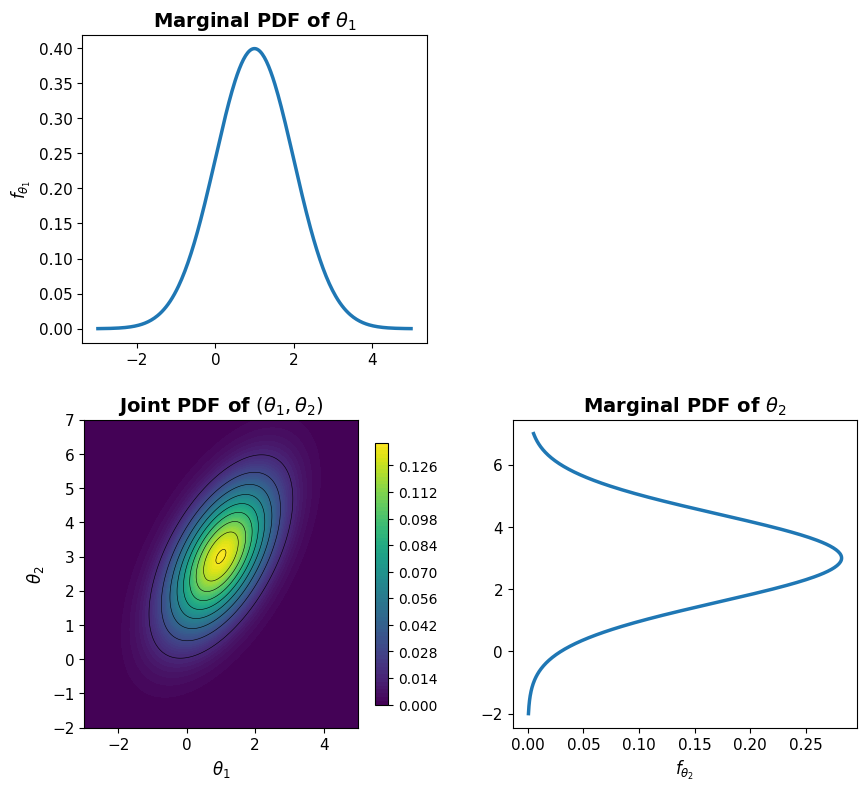

In [7]:
mean = np.array([1.0, 3.0])
cov = np.array([[1.0, 0.8],
                [0.8, 2.0]])

x = np.linspace(-3, 5, 300)
y = np.linspace(-2, 7, 300)

fig, ax = plot_bivariate_gauss(x, y, mean, cov)
plt.show()


In [ ]:
num_samples = 10000
dim = 2
#initial_sample = np.random.randn(2) # random location
initial_sample = np.array([10, 10])

prop_sampler = lambda x: proposal_rw_isotropic_sampler(x, std=2)
prop_logpdf = lambda x, y: proposal_rw_isotropic_logpdf(x, y, std=2)


samples, ar = mh_mcmc(initial_sample, num_samples, target_logpdf_gauss, prop_logpdf, prop_sampler)

print("Accepted Samples Ratio:", ar)